# 英国电力需求时序预测 —— 基于 Transformer

本项目使用英国国家电网的历史电力需求数据，通过 **Transformer** 模型进行时序预测。

主要步骤：
* **[EDA 与特征工程](#eda_fe)** — 数据清洗、特征创建、趋势与季节性分析
* **[Transformer 模型](#transformer)** — 使用 PyTorch 实现 Transformer 进行电力需求预测
* **[结果分析](#results)** — 模型评估与可视化

# 目录
* [EDA 与特征工程](#eda_fe)
* [Transformer 模型](#transformer)
* [结果分析](#results)

In [83]:
import datetime
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 检测设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cuda


## 超参数配置

所有可调参数集中在此处，方便统一修改和实验对比。

In [84]:
# ============================================================
# 超参数配置 —— 所有可调参数集中在此
# ============================================================

# --- 随机种子 ---
SEED = 221

# --- 数据划分 ---
THRESHOLD_DATE_1 = "06-01-2019"  # 训练集/测试集分界
THRESHOLD_DATE_2 = "06-01-2021"  # 测试集/保留集分界

# --- 序列窗口 ---
SEQ_LEN = 48  # 滑动窗口长度（48 = 一天的半小时采样数）

# --- DataLoader ---
BATCH_SIZE = 144

# --- Transformer 模型结构 ---
D_MODEL = 64           # 模型内部维度
NHEAD = 4              # 注意力头数
NUM_LAYERS = 2         # Transformer Encoder 层数
DIM_FEEDFORWARD = 128  # 前馈网络隐藏层维度
DROPOUT = 0.5          # Dropout 比率

# --- 训练 ---
NUM_EPOCHS = 100
LEARNING_RATE = 5e-4
PATIENCE = 12         # 早停耐心值
LR_FACTOR = 0.5        # 学习率衰减倍率
LR_PATIENCE = 5        # 学习率衰减耐心值

print("超参数配置完成")

超参数配置完成


<a id="eda_fe"></a>
## 图表默认参数

设置全局字体和字号，避免每次画图都重复设置。

In [85]:
# 设置默认字体和字号
small_size = 12
medium_size = 14
large_size = 16

matplotlib.rc("font", size=small_size)
matplotlib.rc("axes", titlesize=small_size)
matplotlib.rc("axes", labelsize=medium_size)
matplotlib.rc("xtick", labelsize=small_size)
matplotlib.rc("ytick", labelsize=small_size)
matplotlib.rc("legend", fontsize=small_size)
matplotlib.rc("axes", titlesize=large_size)

# 加载数据

使用英国国家电网 2009-2024 年的历史电力需求数据。

In [86]:
df = pd.read_csv("data/historic_demand_2009_2024_noNaN.csv")

# 列名转小写
df.columns = df.columns.str.lower()

df.sample(n=7)

,settlement_date,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
147732,2017-06-21 03:00:00,7,3:00:00,21436,23725,19626,1108,5143,0,12025,0,1789,405,0,787,245,288,0,0
138687,2016-12-14 15:30:00,32,15:30:00,41695,44638,37835,1106,5113,120,11503,0,13,-974,0,-902,-454,0,0,0
163546,2018-05-16 15:00:00,31,15:00:00,29946,31334,27064,1934,5859,3910,13052,0,13,1995,0,0,-416,-459,0,0
32663,2010-11-18 13:30:00,28,13:30:00,45713,48820,41453,1195,2139,4,66,0,5,-2052,0,0,-450,0,0,0
38804,2011-03-26 12:00:00,25,12:00:00,37370,38263,33712,215,1737,27,128,0,7,1000,0,0,-286,0,0,0
232298,2022-04-18 03:00:00,7,3:00:00,18677,20450,17108,1207,6545,0,13788,0,455,13,11,96,-189,0,778,1
115925,2015-08-28 09:30:00,20,9:30:00,32319,32838,29334,1402,3977,3580,8833,0,15,2000,0,969,17,-4,0,0


In [87]:
df.describe()

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
count,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000
mean,24.497357,31187.041370,32685.811143,28389.589217,1272.085027,4453.970263,880.245314,8705.061549,6.668416,304.497031,926.247609,53.998768,504.137998,-125.145276,-51.106742,176.336876,0.022405
std,13.852025,7831.306542,7598.781279,7091.113104,966.548452,1955.825654,1710.954426,5869.536138,39.197650,528.163447,1068.846762,354.179475,541.678428,230.383910,263.267266,422.130995,0.147996
min,1.000000,13367.000000,16513.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,-2056.000000,-1030.000000,-1215.000000,-505.000000,-585.000000,-1023.000000,0.000000
25%,12.000000,24907.750000,26608.000000,22676.750000,552.000000,2109.000000,0.000000,2046.000000,0.000000,8.000000,271.000000,0.000000,0.000000,-303.000000,-209.000000,0.000000,0.000000
50%,24.000000,30491.000000,31800.000000,27753.000000,1018.000000,4831.000000,0.000000,11503.000000,0.000000,11.000000,1183.000000,0.000000,726.000000,-148.000000,0.000000,0.000000,0.000000
75%,36.000000,36914.000000,38112.000000,33616.000000,1729.000000,6527.000000,889.000000,13080.000000,0.000000,366.000000,1892.000000,0.000000,994.000000,25.000000,0.000000,338.000000,0.000000
max,48.000000,59095.000000,60147.000000,53325.000000,5930.000000,6622.000000,11224.000000,17197.000000,893.000000,2019.000000,2066.000000,1016.000000,1143.000000,499.000000,504.000000,1033.000000,1.000000


In [88]:
df.shape

(278512, 19)

<a id='eda'></a>
# EDA 与特征工程

## 数据理解

目标变量为 **TSD**（输电系统需求，单位 MW）。`settlement_period` 为每日的半小时采样周期（每天48个点）。

In [89]:
# 按日期排序
df.sort_values(by=["settlement_date", "settlement_period"], inplace=True, ignore_index=True)

## 数据准备

- 删除含 NaN 的列（nsl_flow, eleclink_flow）
- 删除 settlement_period > 48 的异常行
- 删除 tsd 为 0 的异常天

In [90]:
# 删除含大量缺失值的列（如果存在）
for col in ["nsl_flow", "eleclink_flow"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# 删除异常的 settlement_period
df.drop(index=df[df["settlement_period"] > 48].index, inplace=True)
df.reset_index(drop=True, inplace=True)

# 删除 tsd 为 0 的整天数据
null_days = df.loc[df["tsd"] == 0.0, "settlement_date"].unique().tolist()
null_days_index = []
for day in null_days:
    null_days_index.append(df[df["settlement_date"] == day].index.tolist())
null_days_index = [item for sublist in null_days_index for item in sublist]
if null_days_index:
    df.drop(index=null_days_index, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"清洗后数据形状: {df.shape}")

清洗后数据形状: (278512, 19)


## 设置日期时间索引

In [91]:
# 将 settlement_date 设为日期时间索引
df["settlement_date"] = pd.to_datetime(df["settlement_date"])
df.set_index("settlement_date", inplace=True)
df.sort_index(inplace=True)

df.head()

,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
settlement_date,,,,,,,,,,,,,,,,,,
2009-01-01 00:00:00,1,0:00:00,37910,38704,33939,54,1403,0,0,0,33,2002,0,0,-161,0,0,1
2009-01-01 00:30:00,2,0:30:00,38047,38964,34072,53,1403,0,0,0,157,2002,0,0,-160,0,0,1
2009-01-01 01:00:00,3,1:00:00,37380,38651,33615,53,1403,0,0,0,511,2002,0,0,-160,0,0,1
2009-01-01 01:30:00,4,1:30:00,36426,37775,32526,50,1403,0,0,0,589,1772,0,0,-160,0,0,1
2009-01-01 02:00:00,5,2:00:00,35687,37298,31877,50,1403,0,0,0,851,1753,0,0,-160,0,0,1


## 特征创建

从日期索引中提取时间特征，并添加年度滞后特征。

In [92]:
def create_features(df):
    """从时间索引中提取时间特征"""
    df = df.copy()
    df["day_of_month"] = df.index.day
    df["day_of_week"] = df.index.day_of_week
    df["day_of_year"] = df.index.day_of_year
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["week_of_year"] = df.index.isocalendar().week.astype("int64")
    return df

def add_lags(df):
    """添加过去三年的滞后特征"""
    target_map = df["tsd"].to_dict()
    df["lag1"] = (df.index - pd.Timedelta("364 days")).map(target_map)
    df["lag2"] = (df.index - pd.Timedelta("728 days")).map(target_map)
    df["lag3"] = (df.index - pd.Timedelta("1092 days")).map(target_map)
    return df

df = create_features(df)
df = add_lags(df)
df.sample(n=5)

,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,day_of_month,day_of_week,day_of_year,quarter,month,year,week_of_year,lag1,lag2,lag3
settlement_date,,,,,,,,,,,,,,,,,,,,,
2015-12-15 16:00:00,33,16:00:00,46504,47736,42331,1988,4013,0,9063,0,...,15,1,349,4,12,2015,51,50964.0,50620.0,52070.0
2012-02-12 15:00:00,31,15:00:00,43355,46138,39301,193,1950,88,1335,0,...,12,6,43,1,2,2012,6,41621.0,44729.0,40834.0
2017-07-02 18:30:00,38,18:30:00,27079,27363,24396,1569,5143,2720,12372,222,...,2,6,183,3,7,2017,26,28114.0,29889.0,31038.0
2013-09-04 10:00:00,21,10:00:00,37810,38693,34535,506,2468,1590,2949,156,...,4,2,247,3,9,2013,36,38441.0,39286.0,41039.0
2022-03-03 00:30:00,2,0:30:00,25896,28018,24212,2435,6545,0,13731,0,...,3,3,62,1,3,2022,9,29145.0,32121.0,27223.0


## 特征分析

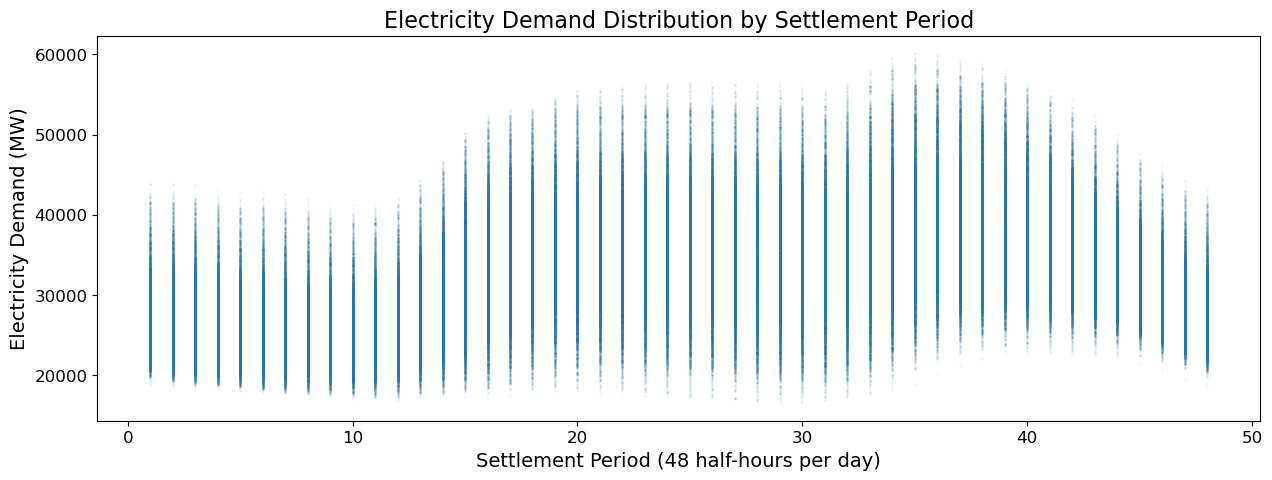

In [93]:
# 每日不同时段的用电分布
fig, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df["settlement_period"], df["tsd"], alpha=0.05, s=1)
ax.set_xlabel("Settlement Period (48 half-hours per day)")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_title("Electricity Demand Distribution by Settlement Period");

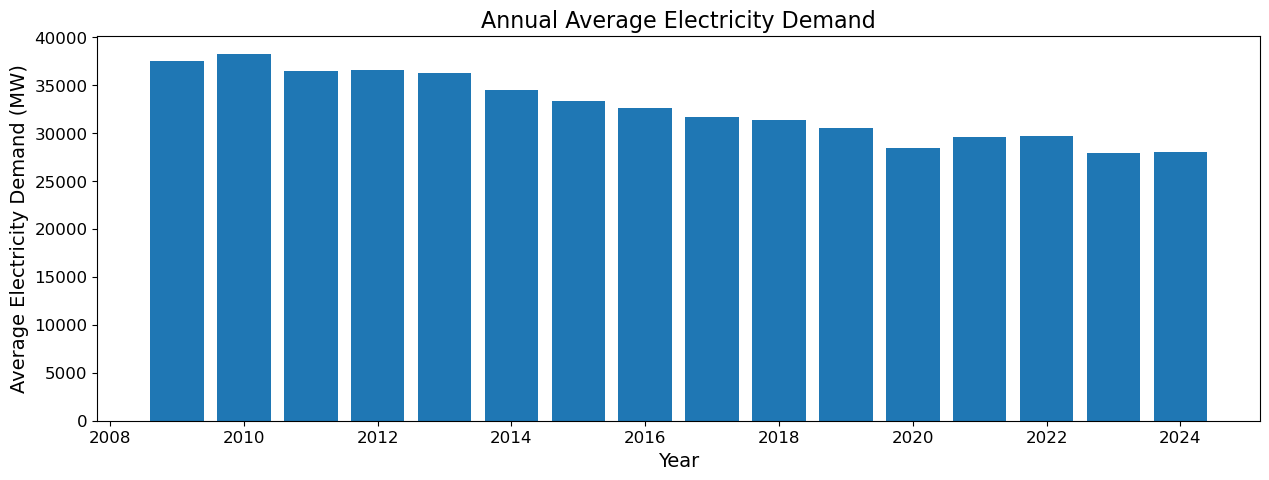

In [94]:
# 按年份的用电分布
fig, ax = plt.subplots(figsize=(15, 5))
yearly_mean = df.groupby("year")["tsd"].mean()
ax.bar(yearly_mean.index, yearly_mean.values)
ax.set_xlabel("Year")
ax.set_ylabel("Average Electricity Demand (MW)")
ax.set_title("Annual Average Electricity Demand");

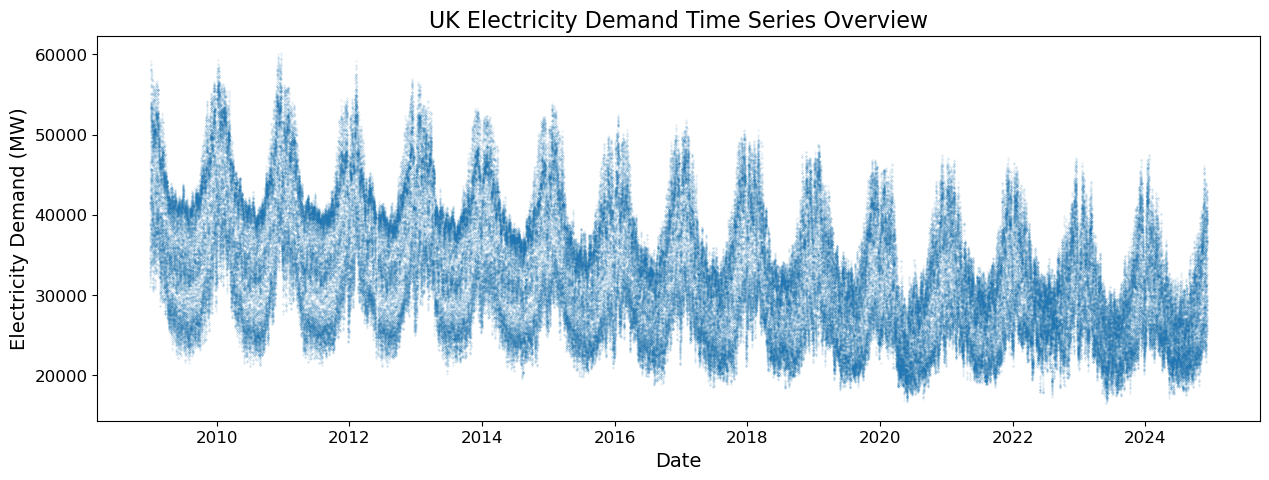

In [95]:
# 时间序列总览
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df["tsd"], ".", markersize=0.5, alpha=0.3)
ax.set_xlabel("Date")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_title("UK Electricity Demand Time Series Overview");

# 时序预测模型

## 评估指标

In [96]:
def mean_absolute_percentage_error(y_true, y_pred):
    """计算平均绝对百分比误差 (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mape

## 数据划分

将数据分为训练集、测试集和保留集（hold-out）。

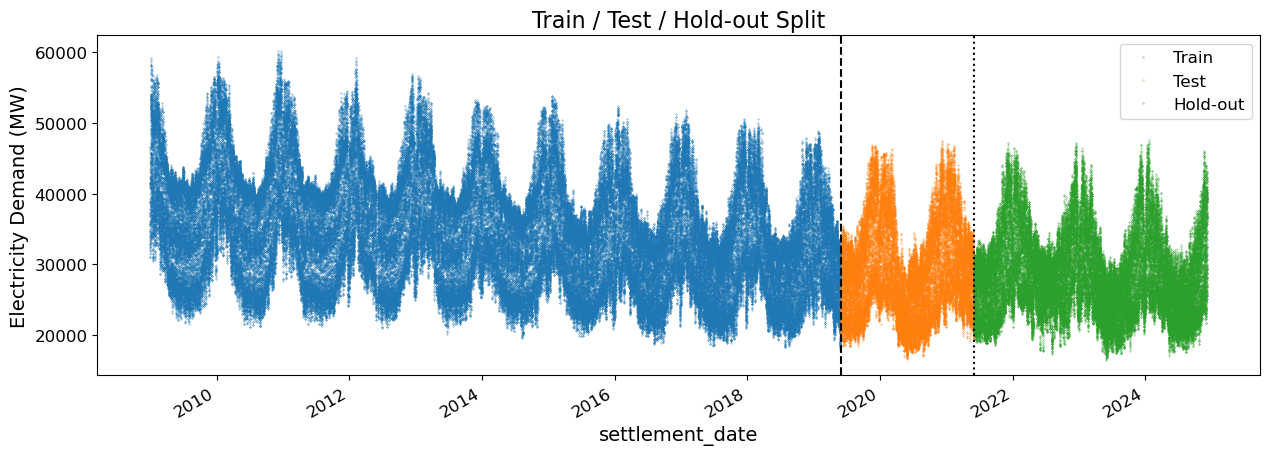

In [97]:
# 设置随机种子
torch.manual_seed(SEED)
np.random.seed(SEED)

train_data = df.loc[df.index < THRESHOLD_DATE_1]
test_data = df.loc[(df.index >= THRESHOLD_DATE_1) & (df.index < THRESHOLD_DATE_2)]
hold_out_data = df.loc[df.index >= THRESHOLD_DATE_2]

# 可视化数据划分
fig, ax = plt.subplots(figsize=(15, 5))
train_data["tsd"].plot(ax=ax, label="Train", style=".", markersize=0.5)
test_data["tsd"].plot(ax=ax, label="Test", style=".", markersize=0.5)
hold_out_data["tsd"].plot(ax=ax, label="Hold-out", style=".", markersize=0.5)
ax.axvline(THRESHOLD_DATE_1, color="k", ls="--")
ax.axvline(THRESHOLD_DATE_2, color="k", ls=":")
ax.set_title("Train / Test / Hold-out Split")
ax.set_ylabel("Electricity Demand (MW)")
plt.legend();

In [98]:
# 定义特征和目标变量
FEATURES = [
    "is_holiday",
    "settlement_period",
    "day_of_month",
    "day_of_week",
    "day_of_year",
    "quarter",
    "month",
    "year",
    "week_of_year",
]
TARGET = "tsd"

X_train = train_data[FEATURES]
y_train = train_data[TARGET]

X_test = test_data[FEATURES]
y_test = test_data[TARGET]

X_hold_out = hold_out_data[FEATURES]
y_hold_out = hold_out_data[TARGET]

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}, 保留集: {X_hold_out.shape}")

训练集: (181802, 9), 测试集: (35084, 9), 保留集: (61626, 9)


<a id='transformer'></a>
# Transformer 时序预测模型

使用 PyTorch 实现 Transformer 模型。相比 LSTM，Transformer 通过自注意力机制能更好地捕捉长距离依赖关系。

## 数据预处理

需要对数据进行归一化（MinMaxScaler 用 numpy 手动实现），并构建序列窗口用于 Transformer 输入。

In [99]:
# 用 numpy 手动实现 MinMaxScaler
FEATURES_TARGET = FEATURES + [TARGET]
train_data_np = train_data[FEATURES_TARGET].values.astype(np.float32)
test_data_np = test_data[FEATURES_TARGET].values.astype(np.float32)

# 在训练集上计算 min 和 max
data_min = train_data_np.min(axis=0)
data_max = train_data_np.max(axis=0)
data_range = data_max - data_min
data_range[data_range == 0] = 1.0  # 防止除以零

# 归一化到 [0, 1]
train_scaled = (train_data_np - data_min) / data_range
test_scaled = (test_data_np - data_min) / data_range

print(f"训练集归一化后形状: {train_scaled.shape}")
print(f"测试集归一化后形状: {test_scaled.shape}")

训练集归一化后形状: (181802, 10)
测试集归一化后形状: (35084, 10)


## 构建序列窗口

Transformer 需要序列输入。我们使用滑动窗口将数据组织为 `(batch, seq_len, features)` 的格式。

In [100]:
def create_sequences(data, seq_len):
    """将数据按滑动窗口切分为序列"""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :-1])   # 特征
        y.append(data[i+seq_len, -1])       # 目标（下一个时间步的 tsd）
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(train_scaled, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(test_scaled, SEQ_LEN)

print(f"训练序列: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"测试序列: X={X_test_seq.shape}, y={y_test_seq.shape}")

训练序列: X=(181754, 48, 9), y=(181754,)
测试序列: X=(35036, 48, 9), y=(35036,)


In [101]:
# 转换为 PyTorch 张量并创建 DataLoader
train_dataset = TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.float32),
    torch.tensor(y_train_seq, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_seq, dtype=torch.float32),
    torch.tensor(y_test_seq, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"训练批次数: {len(train_loader)}, 测试批次数: {len(test_loader)}")

训练批次数: 1263, 测试批次数: 244


## Transformer 模型定义

数据流向：`输入(9维特征) → 线性投影(d_model维) → 位置编码 → Transformer Encoder × N层 → 取最后时间步 → 全连接回归输出`

In [102]:
class PositionalEncoding(nn.Module):
    """
    正弦-余弦位置编码
    为序列中的每个位置生成唯一的编码向量，让模型能区分不同时间步
    """
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # 创建位置编码矩阵 (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # 位置索引: [0, 1, 2, ..., max_len-1]，形状 (max_len, 1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # 频率缩放因子，控制不同维度的振荡频率
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )

        # 偶数维度用 sin，奇数维度用 cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])

        # 增加 batch 维度: (1, max_len, d_model)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # 将位置编码加到输入上，只取前 seq_len 个位置
        return x + self.pe[:, :x.size(1), :]


class TimeSeriesTransformer(nn.Module):
    """
    基于 Transformer Encoder 的时序预测模型

    数据流:
        输入 (batch, seq_len, n_features)
          ↓ Linear 投影
        (batch, seq_len, d_model)
          ↓ + 位置编码
        (batch, seq_len, d_model)
          ↓ Transformer Encoder × num_layers
        (batch, seq_len, d_model)
          ↓ 取最后一个时间步
        (batch, d_model)
          ↓ 全连接回归头
        (batch,)  → 预测值
    """
    def __init__(self, n_features, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()

        # 第1层：输入投影，将原始特征维度映射到模型内部维度
        self.input_proj = nn.Linear(n_features, d_model)

        # 第2层：位置编码
        self.pos_enc = PositionalEncoding(d_model)

        # 第3层：Transformer 编码器（堆叠 num_layers 层）
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 第4层：回归输出头
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x 形状: (batch, seq_len, n_features)

        # 步骤1: 投影到 d_model 维
        x = self.input_proj(x)    # → (batch, seq_len, d_model)

        # 步骤2: 加上位置编码
        x = self.pos_enc(x)       # → (batch, seq_len, d_model)

        # 步骤3: 通过 Transformer 编码器
        x = self.encoder(x)       # → (batch, seq_len, d_model)

        # 步骤4: 取最后一个时间步的输出作为整个序列的表示
        x = x[:, -1, :]           # → (batch, d_model)

        # 步骤5: 通过回归头输出预测值
        x = self.head(x)          # → (batch, 1)

        return x.squeeze(-1)      # → (batch,)


# 实例化模型
model = TimeSeriesTransformer(
    n_features=len(FEATURES),
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
).to(device)

print(model)
print(f"\n可训练参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TimeSeriesTransformer(
  (input_proj): Linear(in_features=9, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.5, inplace=False)
        (dropout2): Dropout(p=0.5, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=32, out_featu

## 模型训练

使用 RMSE 损失函数和 Adam 优化器，并实现早停机制。

In [103]:
# RMSE 损失函数
class RMSELoss(nn.Module):
    def forward(self, pred, target):
        return torch.sqrt(torch.mean((pred - target) ** 2))

# 损失函数、优化器、学习率调度器
criterion = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE
)

# 训练记录
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):

    # ---- 训练阶段 ----
    model.train()
    total_train_loss = 0.0
    num_train_batches = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        num_train_batches += 1

    avg_train_loss = total_train_loss / num_train_batches

    # ---- 验证阶段 ----
    model.eval()
    total_val_loss = 0.0
    num_val_batches = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            total_val_loss += loss.item()
            num_val_batches += 1

    avg_val_loss = total_val_loss / num_val_batches

    # ---- 记录损失 ----
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # ---- 学习率调度 ----
    scheduler.step(avg_val_loss)

    # ---- 早停检查 ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    # ---- 打印日志 ----
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"训练 RMSE: {avg_train_loss:.6f} | "
              f"验证 RMSE: {avg_val_loss:.6f} | "
              f"耐心: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n早停触发于 Epoch {epoch+1}")
        break

# 恢复最优模型权重
model.load_state_dict(best_model_state)
model.to(device)
print("已加载最优模型权重")

Epoch   1/100 | 训练 RMSE: 0.128918 | 验证 RMSE: 0.067732 | 耐心: 0/12
Epoch   2/100 | 训练 RMSE: 0.079098 | 验证 RMSE: 0.067401 | 耐心: 0/12
Epoch   3/100 | 训练 RMSE: 0.073806 | 验证 RMSE: 0.059110 | 耐心: 0/12
Epoch   5/100 | 训练 RMSE: 0.069358 | 验证 RMSE: 0.061239 | 耐心: 2/12
Epoch   6/100 | 训练 RMSE: 0.067409 | 验证 RMSE: 0.057778 | 耐心: 0/12
Epoch   8/100 | 训练 RMSE: 0.065982 | 验证 RMSE: 0.057227 | 耐心: 0/12
Epoch   9/100 | 训练 RMSE: 0.065074 | 验证 RMSE: 0.054018 | 耐心: 0/12
Epoch  10/100 | 训练 RMSE: 0.064618 | 验证 RMSE: 0.058211 | 耐心: 1/12
Epoch  15/100 | 训练 RMSE: 0.063360 | 验证 RMSE: 0.061908 | 耐心: 6/12
Epoch  20/100 | 训练 RMSE: 0.061393 | 验证 RMSE: 0.055732 | 耐心: 11/12

早停触发于 Epoch 21
已加载最优模型权重


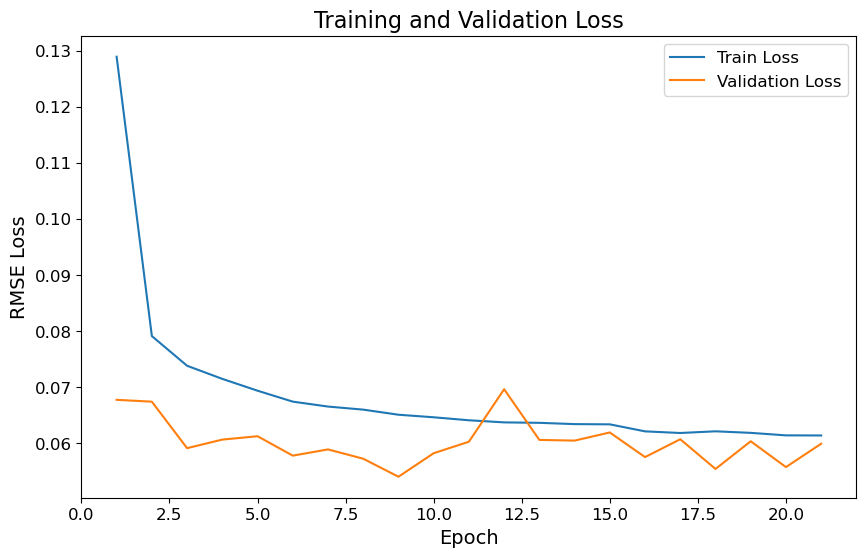

In [104]:
# 绘制训练和验证损失曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE Loss")
ax.set_title("Training and Validation Loss")
ax.legend(loc="best");

## 预测与反归一化

模型训练在归一化数据上进行，因此需要将预测结果反归一化回原始尺度。

In [105]:
# 在测试集上预测
model.eval()
predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())

# 拼接所有 batch 的预测结果
pred_scaled = np.concatenate(predictions)

# 反归一化：将 [0,1] 范围的预测值还原到原始尺度
# 公式：原始值 = 归一化值 × (max - min) + min
tsd_min = data_min[-1]     # tsd 列的最小值
tsd_range = data_range[-1] # tsd 列的 max - min
pred_original = pred_scaled * tsd_range + tsd_min

# 构建结果 DataFrame
# 注意：由于滑动窗口，测试集前 SEQ_LEN 个样本没有预测值
result_frame = y_test.iloc[SEQ_LEN:].to_frame()
result_frame["pred_transformer"] = pred_original

print(f"预测结果: {len(pred_original)} 个样本")

预测结果: 35036 个样本


<a id='results'></a>
# 结果分析

## 测试集预测可视化

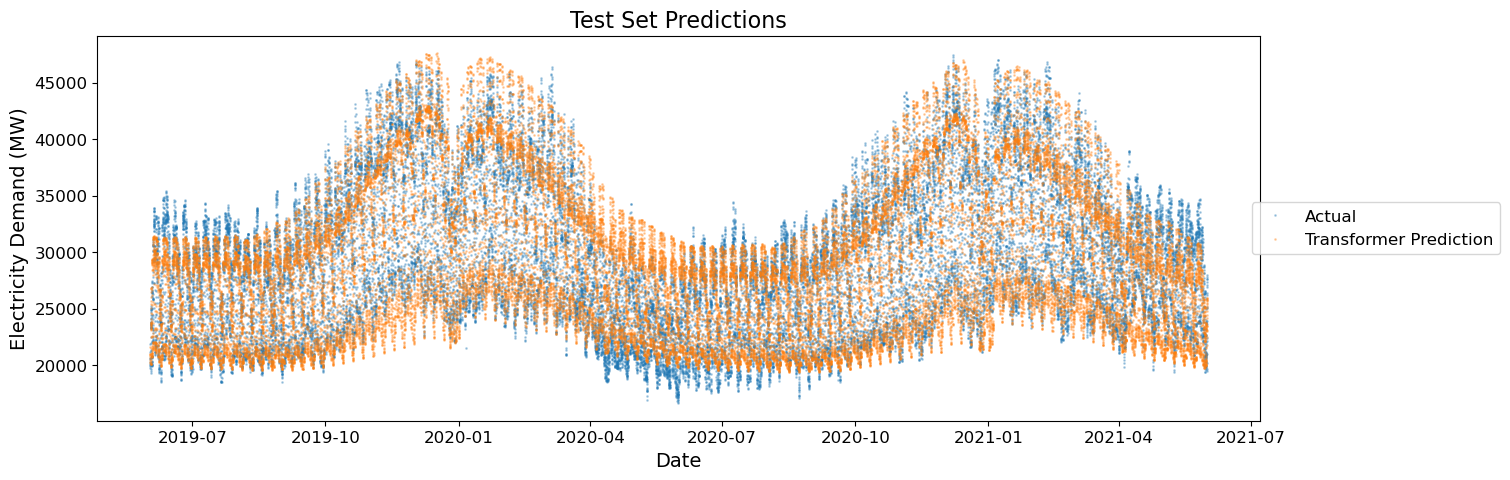

In [106]:
# 测试集全局预测对比
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(result_frame.index, result_frame["tsd"], "o", markersize=1, alpha=0.3, label="Actual")
ax.plot(result_frame.index, result_frame["pred_transformer"], "o", markersize=1, alpha=0.3, label="Transformer Prediction")
ax.legend(loc="center", bbox_to_anchor=(1.1, 0.5))
ax.set_title("Test Set Predictions")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_xlabel("Date");

### 两周细节对比

选取一段两周的时间窗口，观察模型对日内模式的捕捉能力。

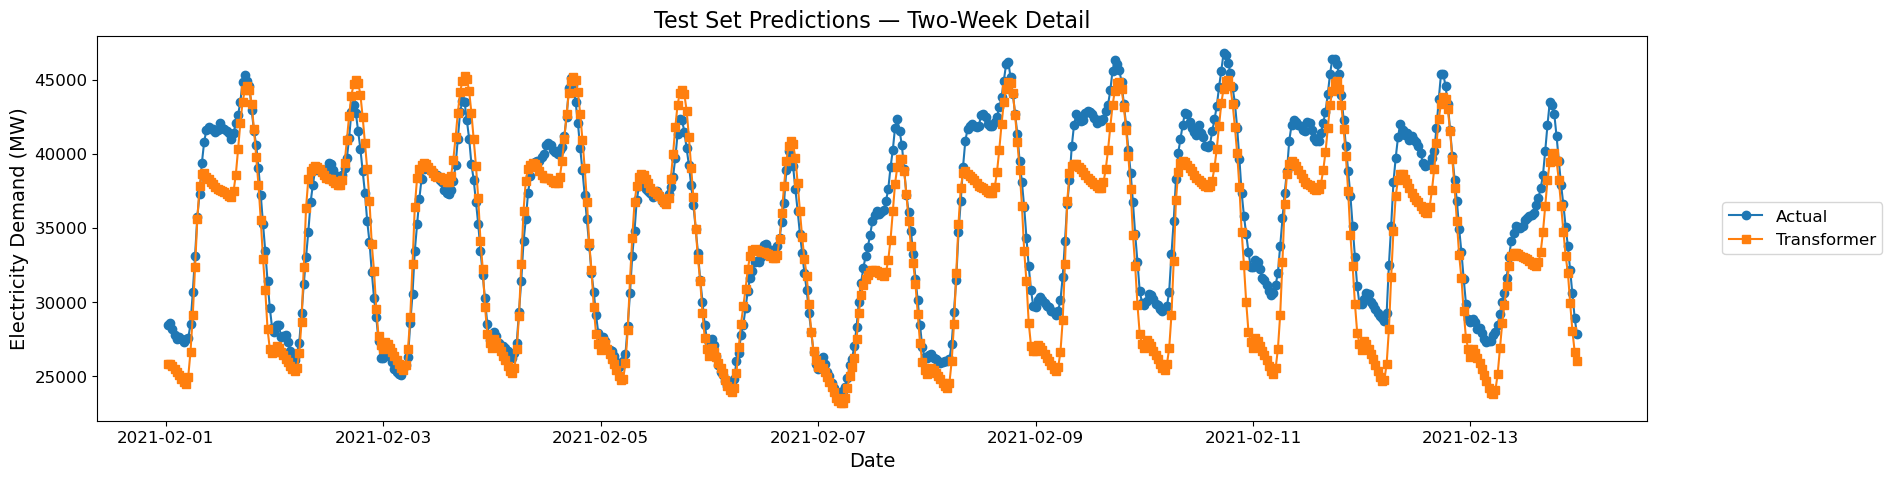

In [107]:
begin = "02-01-2021"
end = "02-14-2021"

mask = (result_frame.index > begin) & (result_frame.index < end)

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(result_frame.loc[mask].index, result_frame.loc[mask]["tsd"], "-o", label="Actual")
ax.plot(result_frame.loc[mask].index, result_frame.loc[mask]["pred_transformer"], "-s", label="Transformer")
ax.legend(loc="center", bbox_to_anchor=(1.1, 0.5))
ax.set_title("Test Set Predictions — Two-Week Detail")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_xlabel("Date");

通过折线图可以确认 Transformer 预测不是原始数据的简单滞后版本，而是真正捕捉到了日内和周内的用电模式。

## 性能指标

In [108]:
mape_transformer = mean_absolute_percentage_error(
    result_frame["tsd"], result_frame["pred_transformer"]
)

rmse_transformer = np.sqrt(np.mean(
    (result_frame["tsd"].values - result_frame["pred_transformer"].values) ** 2
))

print(f"Transformer 模型 MAPE: {mape_transformer:.2f}%")
print(f"Transformer 模型 RMSE: {rmse_transformer:.2f} MW")

Transformer 模型 MAPE: 6.68%
Transformer 模型 RMSE: 2459.80 MW


## 结果总结

In [109]:
summary_df = pd.DataFrame({
    "Transformer": [mape_transformer, rmse_transformer],
}, index=["MAPE (%)", "RMSE (MW)"])

summary_df.style.format('{:.2f}')

,Transformer
MAPE (%),6.68
RMSE (MW),2459.80


## 总结与展望

**Transformer** 模型利用自注意力机制，能够有效捕捉电力需求数据中的多种季节性模式（日内、周内、年内）。

后续改进方向：
* 尝试不同的序列长度（如 96 或 336 个时间步）
* 增加 Transformer 层数或注意力头数
* 使用概率预测输出（如高斯似然）量化预测的不确定性
* 探索不同的训练-测试划分策略

In [110]:
print(f"Train losses: {train_losses[:10]}")
print(f"Val losses: {val_losses[:10]}")
print(f"Total epochs: {len(train_losses)}")
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Final LR: {optimizer.param_groups[0]['lr']}")


Train losses: [0.12891812970004946, 0.079098044516355, 0.07380618651707967, 0.07146639208164086, 0.06935807244936247, 0.06740880304518335, 0.06653052713553866, 0.06598214493652987, 0.06507399429287687, 0.06461777153733884]
Val losses: [0.06773237031350127, 0.06740094812159411, 0.059110463703753516, 0.06063815162776679, 0.06123944961267416, 0.057777510765084965, 0.05888814660033486, 0.057227075328958814, 0.05401778011201102, 0.058210675009205695]
Total epochs: 21
Best val loss: 0.054018
Final LR: 0.000125
